## 📘 Quadratic Mixed-Integer Benchmark: **QPLIB_0032**

**QPLIB_0032** is a benchmark instance from **QPLIB (Quadratic Programming Library)**, a public collection of quadratic optimization problems used for solver benchmarking and research. This instance is classified as **QML**: a **quadratic objective** with **linear constraints**.

🔗 Official instance page:  
https://qplib.zib.de/QPLIB_0032.html

---

### 🧮 Problem Structure (from QPLIB)

QPLIB reports the following key statistics for **QPLIB_0032**:

- **Variables:** 100  
  - **Binary variables:** 50  
  - **Continuous variables:** 50 (these have only one bound reported by QPLIB)  
- **Constraints:** 52 (all **linear**)  
- **Quadratic constraints:** 0 (none)  
- **Objective:** **quadratic**, **indefinite**  
  - Objective matrix has **25 negative** and **25 positive** eigenvalues (nonconvex)  
  - Quadratic terms in objective: 1274  

This makes the instance a **Mixed-Integer Quadratic Program (MIQP)** with **linear constraints**, but a **nonconvex (indefinite) quadratic objective**.

---

### 🧠 Abstract Mathematical Form

A standard representation of this problem class is:

$$
\begin{aligned}
\min \quad & \frac{1}{2}x^\top Q x + c^\top x \\
\text{s.t.}\quad & A x \le b \\
& x_j \in \{0,1\} \quad \forall j \in \mathcal{B} \\
& \ell \le x \le u
\end{aligned}
$$

where:
- $x \in \mathbb{R}^{100}$ is the decision vector,
- $\mathcal{B}$ indexes the 50 binary variables,
- $Q$ is **indefinite**, implying a **nonconvex** quadratic objective.

---

### ⚠️ Solver Note (important for Gurobi)

Because the quadratic objective is **indefinite (nonconvex)**, solvers typically require explicit nonconvex handling (e.g., Gurobi needs `NonConvex = 2`) to solve the model globally or to attempt spatial branch-and-bound style methods for nonconvex MIQP.

---

### ✅ Reference Solution (for verification)

QPLIB reports a feasible solution point with objective value:

$$
\boxed{z = 10.12639121}
$$

and **zero infeasibility** for that solution point. :contentReference[oaicite:6]{index=6}

This value is useful as a benchmark check when validating model import and solver configuration.

---

### 🗂 What This Notebook Will Do

In this notebook we will:

1. Load the **QPLIB_0032** model (LP/GMS/QPLIB formats supported by QPLIB) :contentReference[oaicite:7]{index=7}  
2. Configure Gurobi appropriately for **nonconvex MIQP** (if using Gurobi)
3. Solve the instance and record solver progress (incumbent, best bound, gap, nodes, runtime)
4. Visualize convergence behavior:
   - incumbent vs time
   - bound vs time
   - gap vs time (log scale)
   - bound tightening vs node count


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 107.3 MB/s eta 0:00:00
Restricted license - for non-production use only - expires 2027-11-29
Read LP format model from file /content/QPLIB_0032.lp
Reading time = 0.00 seconds
obj: 52 rows, 100 columns, 200 nonzeros
Set parameter OutputFlag to value 1
Set parameter NonConvex to value 2
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
NonConvex  2

Optimize a model with 52 rows, 100 columns and 200 nonzeros (Min)
Model fingerprint: 0x9b1f1f9f
Model has 0 linear objective coefficients
Model has 1274 quadratic objective terms
Variable types: 50 continuous, 50 integer (50 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [0e+00, 0e+00]
  QObjective range [2e+00, 7e+03]
  Bounds range     [1e+00

/tmp/ipython-input-2062161879.py:65: RuntimeWarning: divide by zero encountered in log
  plt.plot(times, np.log(bounds), linestyle = "--", label = "Best Bounds")
/tmp/ipython-input-2062161879.py:65: RuntimeWarning: invalid value encountered in log
  plt.plot(times, np.log(bounds), linestyle = "--", label = "Best Bounds")


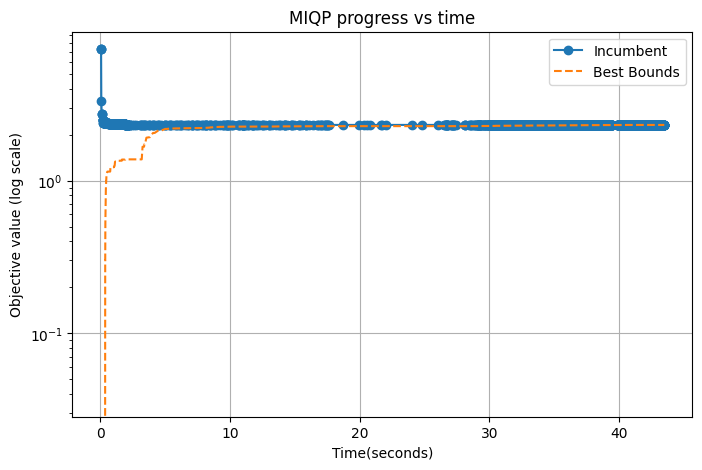

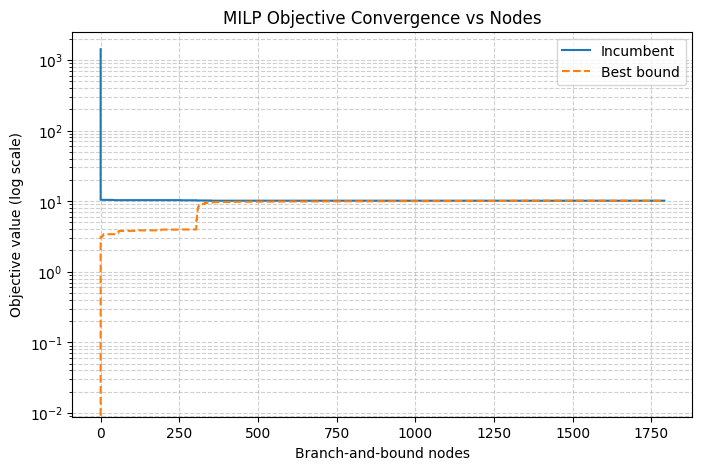

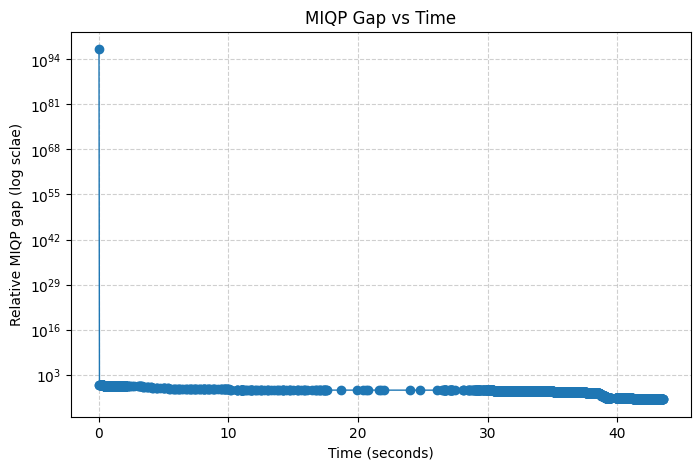

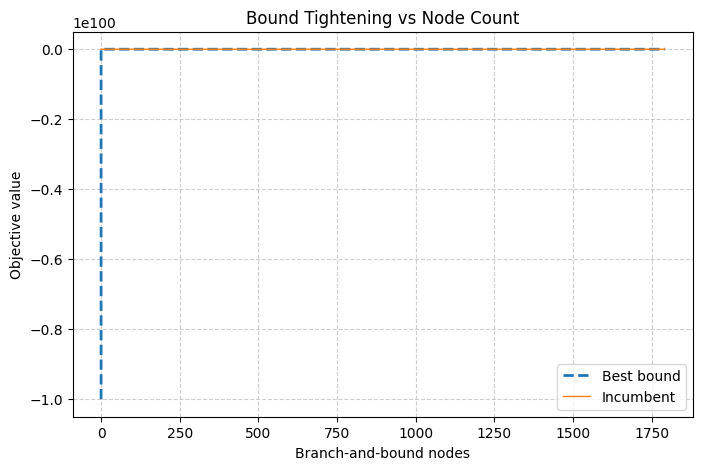

In [1]:
!pip -q install gurobipy
import gurobipy as gp
from gurobipy import GRB
from matplotlib import pyplot as plt
import numpy as np
import os

model_path = "/content/QPLIB_0032.lp"

if not os.path.exists(model_path):
   raise FileNotFoundError(f"Not found: {model_path}")

# reading optimization model from the file: QPLIB_3562.lp.txt
model = gp.read(model_path)
model.Params.OutputFlag = 1 # to print solver output
model.Params.NonConvex = 2

# store run time, bounds, objective function value for visualization of solver performance
times = []
nodes = []
incumbents = []
bounds = [] # Gurobi uses branch-and-bound method for integer/mixed integer programming problems
events = []

# this function is triggered when there is a feasible solution

def cb(model, where):
    if where == GRB.Callback.MIPSOL:
       t = model.cbGet(GRB.Callback.RUNTIME)
       n = model.cbGet(GRB.Callback.MIPSOL_NODCNT)
       obj = model.cbGet(GRB.Callback.MIPSOL_OBJ)
       bnd = model.cbGet(GRB.Callback.MIPSOL_OBJBND)

       times.append(t)
       nodes.append(n)
       incumbents.append(obj)
       bounds.append(bnd)
       events.append("MIPSOL")

    elif where == GRB.Callback.MIP:
       t = model.cbGet(GRB.Callback.RUNTIME)
       n = model.cbGet(GRB.Callback.MIP_NODCNT)
       obj_best = model.cbGet(GRB.Callback.MIP_OBJBST)
       obj_bnd = model.cbGet(GRB.Callback.MIP_OBJBND)

       if obj_best< GRB.INFINITY:
          times.append(t)
          nodes.append(n)
          incumbents.append(obj_best)
          bounds.append(obj_bnd)
          events.append("MIP")

model.optimize(cb) # run the solve with callback

print("Collected points")
print("Status", model.status)
if model.SolCount > 0:
   print("OPtimal value of Objective function", model.ObjVal)
   model.write("/content/solution.sol")
   model.write("/content/model_parsed.lp")

# plot objective vs time
plt.figure(figsize = (8,5))
plt.plot(times, np.log(incumbents), marker = "o", label = "Incumbent")
plt.plot(times, np.log(bounds), linestyle = "--", label = "Best Bounds")
plt.yscale("log")
plt.xlabel("Time(seconds)")
plt.ylabel("Objective value (log scale)")
plt.title("MIQP progress vs time")
plt.grid(True)
plt.legend()
plt.show()

# objective function vs nodes
plt.figure(figsize = (8,5))
plt.plot(nodes, incumbents, label = "Incumbent")
plt.plot(nodes, bounds, linestyle = "--", label = "Best bound")
plt.yscale("log")
plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value (log scale)")
plt.title("MILP Objective Convergence vs Nodes")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# visualiztion of how integrality gas reduces as optimization advances
t = np.asarray(times, dtype =  float)
inc = np.asarray(incumbents, dtype = float)
bnd = np.asarray(bounds, dtype = float)

# keep only finite values
mask = np.isfinite(t) & np.isfinite(inc) & np.isfinite(bnd)
t, inc, bnd = t[mask], inc[mask], bnd[mask]

# relative gap
eps = 1e-12
gap = (inc - bnd)/np.maximum(np.abs(inc),eps)
gap = np.maximum(gap,eps) # to avoid infinite or negative values

order = np.argsort(t)
t, gap = t[order], gap[order]

plt.figure(figsize =(8,5))
plt.plot(t,gap, marker = "o", linewidth = 1)
plt.yscale("log")
plt.xlabel("Time (seconds)")
plt.ylabel("Relative MIQP gap (log sclae)")
plt.title("MIQP Gap vs Time")
plt.grid(True, which = "both", linestyle = "--", alpha = 0.6)
plt.show()

# plotting node count vs best bound

n = np.asarray(nodes, dtype = float)
inc = np.asarray(incumbents, dtype = float)
bnd = np.asarray(bounds, dtype = float)

mask = np.isfinite(n) & np.isfinite(inc) & np.isfinite(bnd)
n, inc, bnd = n[mask], inc[mask], bnd[mask]

# sort by node count
order = np.argsort(n)
n, inc, bnd = n[order], inc[order], bnd[order]

plt.figure(figsize = (8,5))
# Best bound vs nodes (main request)
plt.plot(n, bnd, linestyle="--", linewidth=2, label="Best bound")

# Optional: include incumbent for context
plt.plot(n, inc, linewidth=1, label="Incumbent")

plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value")
plt.title("Bound Tightening vs Node Count")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()



